# 🐱‍🔮 Sudoku Master — Detección y resolución (local)
Foto → **YOLO** detecta recuadro → recorte → perspectiva → 81 celdas → **CNN OCR** → matriz → **backtracking** resuelve

Notebook pensado para ejecutarse en local desde la carpeta `cuadernos/`.
La foto debe estar bien orientada (números legibles).

## PASO 0 · Imports y configuración de rutas

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy
from pathlib import Path
from ultralytics import YOLO

# ── RUTAS ────────────────────────────────────────────────────────────────────
RUTA_YOLO       = Path('../modelos/yolo.pt')
RUTA_MODELO_OCR = Path('../modelos/modelo_ocr.keras')   # CNN entrenada con MNIST
RUTA_IMAGEN     = Path('../img_pruebas/024.png')    # ← cambia por tu foto

print('✓ Imports OK')
print(f'  YOLO:      {RUTA_YOLO}  ({"existe" if RUTA_YOLO.exists() else "NO ENCONTRADO"})')
print(f'  CNN OCR:   {RUTA_MODELO_OCR}  ({"existe" if RUTA_MODELO_OCR.exists() else "NO ENCONTRADO"})')
print(f'  Imagen:    {RUTA_IMAGEN}  ({"existe" if RUTA_IMAGEN.exists() else "NO ENCONTRADA"})')


✓ Imports OK
  YOLO:      ..\modelos\yolo.pt  (existe)
  CNN OCR:   ..\modelos\modelo_ocr.keras  (existe)
  Imagen:    ..\img_pruebas\024.png  (existe)


## PASO 1 · Cargar modelos
YOLO (detecta recuadro) + CNN OCR (lee dígitos)

In [18]:
from tensorflow import keras

modelo_yolo = YOLO(str(RUTA_YOLO))
modelo_ocr  = keras.models.load_model(str(RUTA_MODELO_OCR))

print('✓ YOLO cargado')
print('✓ CNN OCR (MNIST) cargada')
modelo_ocr.summary()


✓ YOLO cargado
✓ CNN OCR (MNIST) cargada


Model: "modelo_ocr_fuentes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,612,672 (9.97 MB)

 Trainable params: 870,826 (3.32 MB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 1,741,654 (6.64 MB)

## PASO 2 · Cargar foto y detectar el recuadro con YOLO

📷 024.png  (1307×897 px)


C:\Users\rober\AppData\Local\Temp\ipykernel_4020\190644969.py:29: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


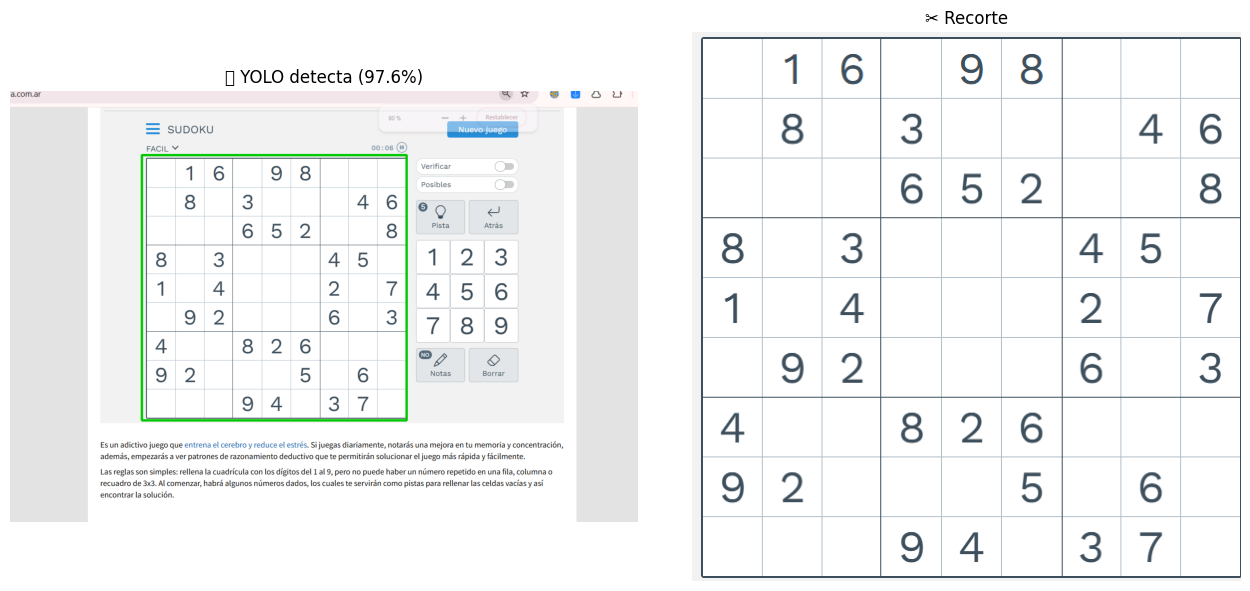

✓ Recuadro: (274,133) → (825,685)


In [19]:
imagen_original = cv2.imread(str(RUTA_IMAGEN))
assert imagen_original is not None, f'No se pudo cargar {RUTA_IMAGEN}'
print(f'📷 {RUTA_IMAGEN.name}  ({imagen_original.shape[1]}×{imagen_original.shape[0]} px)')

# YOLO detecta el recuadro
results = modelo_yolo(imagen_original, verbose=False)

if len(results[0].boxes) == 0:
    print('❌ No se detectó ningún recuadro de sudoku')
else:
    # Coger la caja de mayor área (el sudoku completo)
    boxes = results[0].boxes.xyxy.cpu().numpy()
    areas = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
    idx   = int(np.argmax(areas))
    x1, y1, x2, y2 = map(int, boxes[idx])
    conf = float(results[0].boxes.conf[idx])
    img_recortada = imagen_original[y1:y2, x1:x2]

    img_bbox = imagen_original.copy()
    cv2.rectangle(img_bbox, (x1,y1), (x2,y2), (0,200,0), 4)

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))
    axes[0].imshow(cv2.cvtColor(img_bbox, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'🎯 YOLO detecta ({conf:.1%})')
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(img_recortada, cv2.COLOR_BGR2RGB))
    axes[1].set_title('✂️ Recorte')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    print(f'✓ Recuadro: ({x1},{y1}) → ({x2},{y2})')

## PASO 3 · Corregir perspectiva

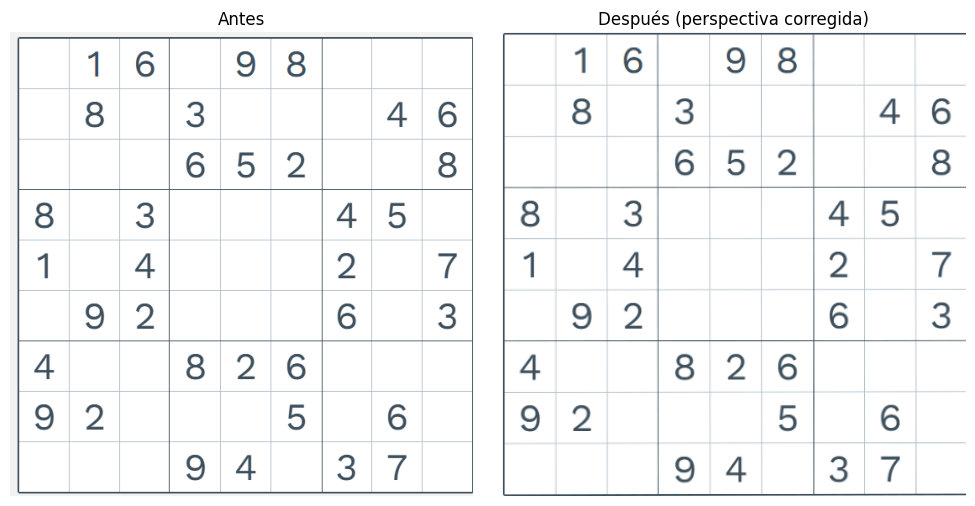

✓ Perspectiva corregida


In [20]:
def ordenar_esquinas(pts):
    pts = pts.reshape(4, 2).astype('float32')
    rect = np.zeros((4, 2), dtype='float32')
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left
    rect[2] = pts[np.argmax(s)]   # bottom-right
    d = np.diff(pts, axis=1).flatten()
    rect[1] = pts[np.argmin(d)]   # top-right
    rect[3] = pts[np.argmax(d)]   # bottom-left
    return rect

def corregir_perspectiva(img):
    """Detecta la cuadrícula INTERIOR (líneas negras) ignorando bordes de color
    como el borde azul del cuaderno. Corrige la perspectiva a un cuadrado de 450x450."""
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gris, (5, 5), 0)
    # adaptiveThreshold detecta las líneas negras de la cuadrícula, robusto a fondos de color
    thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY_INV, 11, 4)
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.dilate(thresh, kernel, iterations=1)

    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contornos:
        print('⚠️ No se encontraron contornos, usando imagen sin corregir')
        return img
    contornos = sorted(contornos, key=cv2.contourArea, reverse=True)
    img_area = img.shape[0] * img.shape[1]

    for c in contornos[:8]:
        if cv2.contourArea(c) < img_area * 0.15:   # la cuadrícula ocupa casi todo el recorte
            continue
        peri   = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) == 4:
            rect = ordenar_esquinas(approx.reshape(4, 2))
        else:
            # Fallback: rectángulo rotado mínimo (siempre da 4 esquinas)
            box  = cv2.boxPoints(cv2.minAreaRect(c))
            rect = ordenar_esquinas(box)
        lado = 450
        dst  = np.array([[0,0],[lado,0],[lado,lado],[0,lado]], dtype='float32')
        M    = cv2.getPerspectiveTransform(rect, dst)
        return cv2.warpPerspective(img, M, (lado, lado))

    print('⚠️ No se encontró cuadrícula clara, usando imagen sin corregir')
    return img

img_corregida = corregir_perspectiva(img_recortada)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img_recortada,  cv2.COLOR_BGR2RGB))
axes[0].set_title('Antes')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img_corregida, cv2.COLOR_BGR2RGB))
axes[1].set_title('Después (perspectiva corregida)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print('✓ Perspectiva corregida')

## PASO 4 · Dividir en 81 celdas

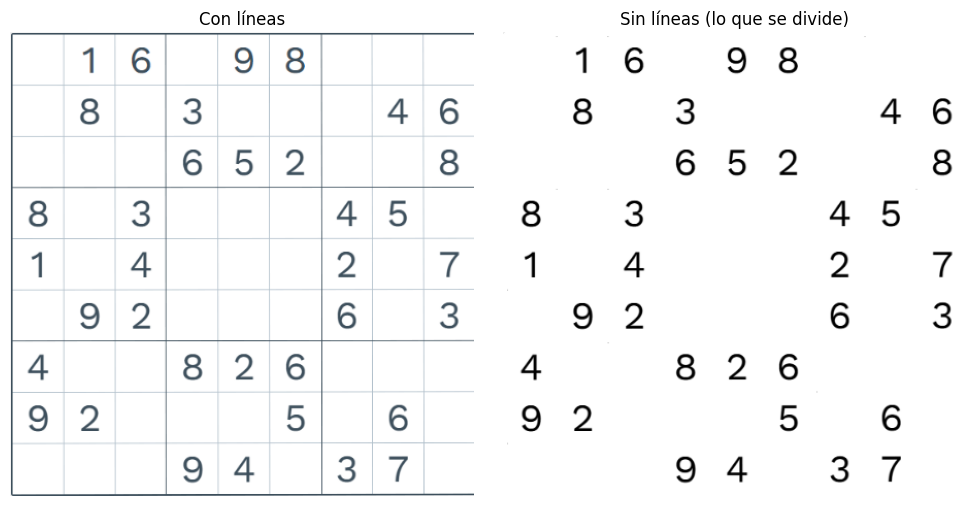

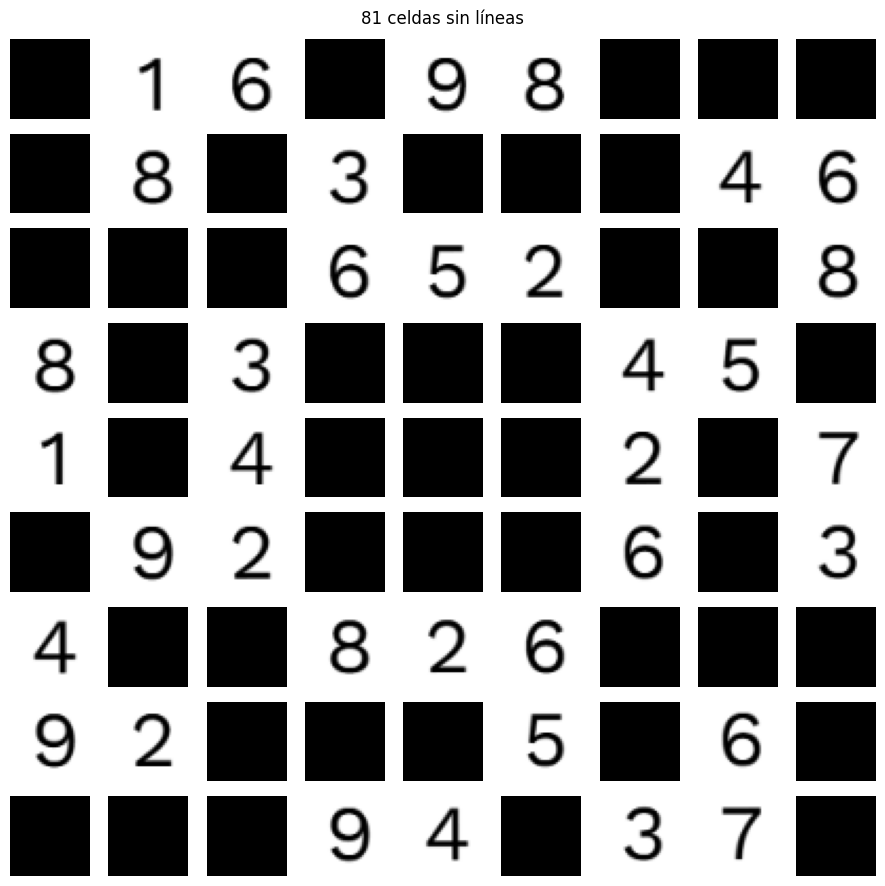

✓ 81 celdas generadas (sin líneas de cuadrícula)


In [21]:
def eliminar_lineas(warped):
    """Borra las líneas de la cuadrícula de toda la imagen a la vez con morfología.
    Así las celdas quedan limpias y la CNN no confunde líneas con trazos del dígito."""
    gris = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    binaria = cv2.adaptiveThreshold(gris, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY_INV, 11, 5)
    # Líneas horizontales largas
    h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (warped.shape[1]//9, 1))
    h_lines  = cv2.morphologyEx(binaria, cv2.MORPH_OPEN, h_kernel)
    # Líneas verticales largas
    v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, warped.shape[0]//9))
    v_lines  = cv2.morphologyEx(binaria, cv2.MORPH_OPEN, v_kernel)
    # Máscara de líneas (un poco engrosada) y rellenar con blanco
    lineas = cv2.dilate(cv2.add(h_lines, v_lines), np.ones((3,3),np.uint8), iterations=1)
    resultado = gris.copy()
    resultado[lineas > 0] = 255
    return resultado

# Eliminar las líneas de la cuadrícula ANTES de dividir en celdas
img_sin_lineas = eliminar_lineas(img_corregida)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img_corregida, cv2.COLOR_BGR2RGB))
axes[0].set_title('Con líneas')
axes[0].axis('off')
axes[1].imshow(img_sin_lineas, cmap='gray')
axes[1].set_title('Sin líneas (lo que se divide)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Dividir en 81 celdas (sobre la imagen SIN líneas)
alto, ancho = img_sin_lineas.shape[:2]
celda_alto  = alto // 9
celda_ancho = ancho // 9
MARGEN = 6

celdas = []
for fila in range(9):
    fila_celdas = []
    for col in range(9):
        y1c = fila * celda_alto + MARGEN
        y2c = y1c + celda_alto - MARGEN * 2
        x1c = col * celda_ancho + MARGEN
        x2c = x1c + celda_ancho - MARGEN * 2
        fila_celdas.append(img_sin_lineas[y1c:y2c, x1c:x2c])
    celdas.append(fila_celdas)

fig, axes = plt.subplots(9, 9, figsize=(9, 9))
for fila in range(9):
    for col in range(9):
        axes[fila][col].imshow(celdas[fila][col], cmap='gray')
        axes[fila][col].axis('off')
plt.suptitle('81 celdas sin líneas', fontsize=12)
plt.tight_layout()
plt.show()
print('✓ 81 celdas generadas (sin líneas de cuadrícula)')

## PASO 5 · Leer dígitos con CNN OCR → matriz

In [22]:
def celda_tiene_digito(celda):
    """Detecta si una celda tiene dígito por contraste centro vs esquinas."""
    gris = celda if len(celda.shape)==2 else cv2.cvtColor(celda, cv2.COLOR_BGR2GRAY)
    gris = cv2.resize(gris.astype(np.float32), (48, 48))
    e = 8
    esquinas = np.concatenate([gris[:e,:e].ravel(), gris[:e,-e:].ravel(),
                                gris[-e:,:e].ravel(), gris[-e:,-e:].ravel()])
    fondo  = np.median(esquinas)
    centro = gris[12:36, 12:36]
    return (np.sum(centro < fondo - 40) / centro.size) > 0.03

def preprocesar_para_cnn(celda):
    """Celda gris (sin líneas) → 28x28 dígito NEGRO sobre fondo BLANCO (como el entrenamiento)."""
    gris = celda if len(celda.shape)==2 else cv2.cvtColor(celda, cv2.COLOR_BGR2GRAY)
    gris = cv2.resize(gris, (28, 28), interpolation=cv2.INTER_AREA)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    gris  = clahe.apply(gris)
    # SIN _INV: dígito negro sobre blanco, igual que el dataset de fuentes
    _, binaria = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return binaria.astype('float32') / 255.0

def predecir_celda(celda, modelo):
    """Clasifica una celda: 0=vacía, 1-9=dígito."""
    if not celda_tiene_digito(celda):
        return 0
    img  = preprocesar_para_cnn(celda).reshape(1, 28, 28, 1)
    pred = modelo.predict(img, verbose=0)[0]
    clase = int(np.argmax(pred))
    if clase == 0:
        clase = int(np.argmax(pred[1:])) + 1
    return clase

sudoku = []
for fila in range(9):
    fila_nums = []
    for col in range(9):
        fila_nums.append(predecir_celda(celdas[fila][col], modelo_ocr))
    sudoku.append(fila_nums)

n = sum(1 for f in sudoku for x in f if x != 0)
print(f'✓ {n} dígitos detectados · {81-n} huecos\n')
print('Sudoku detectado:')
print('─' * 25)
for i, fila in enumerate(sudoku):
    if i % 3 == 0 and i != 0: print('─' * 25)
    s = ''
    for j, num in enumerate(fila):
        if j % 3 == 0 and j != 0: s += '│ '
        s += f'{num if num != 0 else "·"} '
    print(s)


✓ 36 dígitos detectados · 45 huecos

Sudoku detectado:
─────────────────────────
· 1 6 │ · 9 8 │ · · · 
· 8 · │ 3 · · │ · 4 6 
· · · │ 6 5 2 │ · · 8 
─────────────────────────
8 · 3 │ · · · │ 4 5 · 
1 · 4 │ · · · │ 2 · 7 
· 9 2 │ · · · │ 6 · 3 
─────────────────────────
4 · · │ 8 2 6 │ · · · 
9 2 · │ · · 5 │ · 6 · 
· · · │ 9 4 · │ 3 7 · 


## PASO 6 · Verificación: imagen + matriz lado a lado

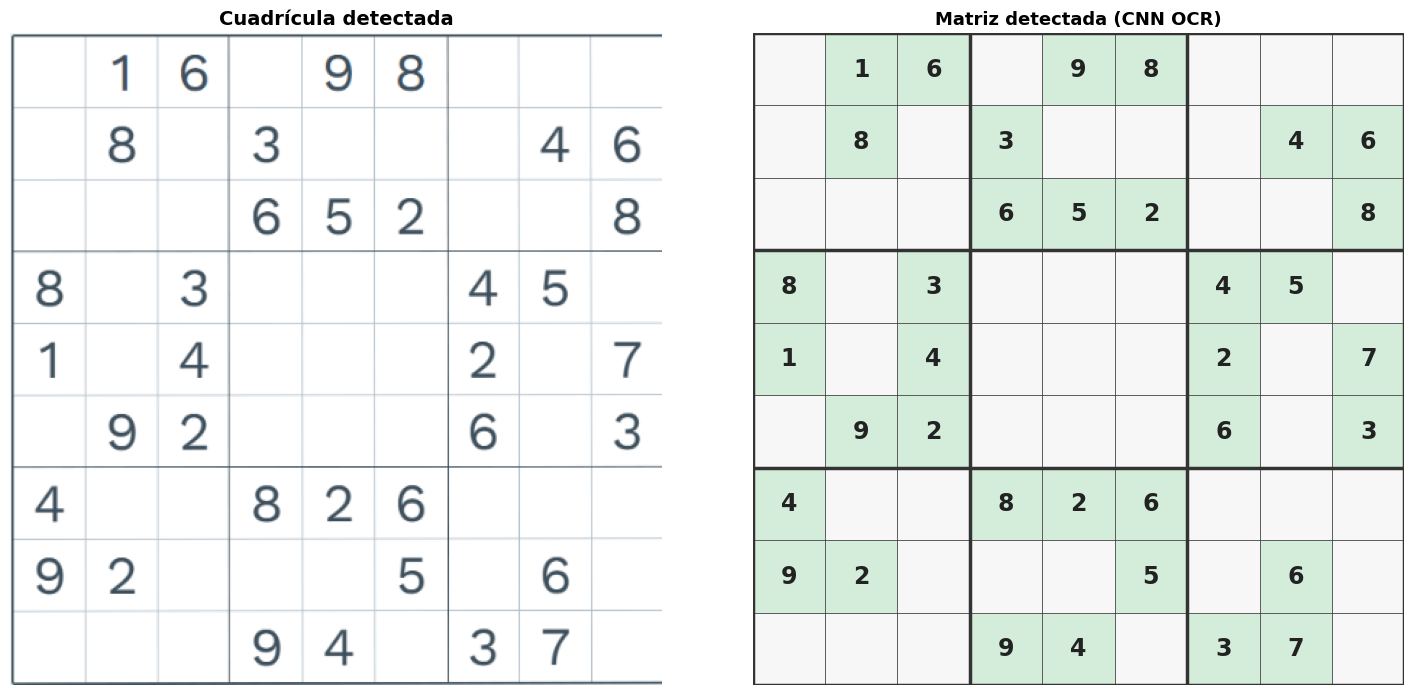

In [23]:
fig = plt.figure(figsize=(15, 7))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(cv2.cvtColor(img_corregida, cv2.COLOR_BGR2RGB))
ax1.set_title('Cuadrícula detectada', fontsize=14, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(1, 2, 2)
ax2.set_xlim(0, 9); ax2.set_ylim(0, 9); ax2.set_aspect('equal'); ax2.axis('off')
ax2.set_title('Matriz detectada (CNN OCR)', fontsize=13, fontweight='bold')
for i in range(9):
    for j in range(9):
        d = sudoku[i][j]
        fondo = '#d4edda' if d != 0 else '#f7f7f7'
        ax2.add_patch(plt.Rectangle((j, 8-i), 1, 1, facecolor=fondo, edgecolor='#bbb', lw=0.5))
        if d != 0:
            ax2.text(j+0.5, 8-i+0.5, str(d), ha='center', va='center',
                     fontsize=17, fontweight='bold', color='#222')
for k in range(10):
    lw = 2.5 if k % 3 == 0 else 0.5
    ax2.axhline(k, color='#333', lw=lw); ax2.axvline(k, color='#333', lw=lw)
plt.tight_layout()
plt.show()

## PASO 7 · Resolver con backtracking

In [24]:
def es_valido(t, fila, col, num):
    if num in t[fila]: return False
    if num in [t[i][col] for i in range(9)]: return False
    bf, bc = (fila//3)*3, (col//3)*3
    for i in range(bf, bf+3):
        for j in range(bc, bc+3):
            if t[i][j] == num: return False
    return True

def backtrack(t):
    for i in range(9):
        for j in range(9):
            if t[i][j] == 0:
                for num in range(1, 10):
                    if es_valido(t, i, j, num):
                        t[i][j] = num
                        if backtrack(t): return True
                        t[i][j] = 0
                return False
    return True

tablero  = copy.deepcopy(sudoku)
resuelto = backtrack(tablero)

if resuelto:
    print('✓ Sudoku resuelto (backtracking):\n')
else:
    print('❌ No se pudo resolver — puede haber errores de lectura en el OCR\n')

print('─' * 25)
for i, fila in enumerate(tablero):
    if i % 3 == 0 and i != 0: print('─' * 25)
    s = ''
    for j, num in enumerate(fila):
        if j % 3 == 0 and j != 0: s += '│ '
        marca = ' ' if sudoku[i][j] != 0 else '*'
        s += f'{num}{marca}'
    print(s)
print('(* = rellenado por backtracking)')

✓ Sudoku resuelto (backtracking):

─────────────────────────
3*1 6 │ 4*9 8 │ 7*2*5*
2*8 5*│ 3 1*7*│ 9*4 6 
7*4*9*│ 6 5 2 │ 1*3*8 
─────────────────────────
8 7*3 │ 2*6*9*│ 4 5 1*
1 6*4 │ 5*8*3*│ 2 9*7 
5*9 2 │ 1*7*4*│ 6 8*3 
─────────────────────────
4 3*7*│ 8 2 6 │ 5*1*9*
9 2 1*│ 7*3*5 │ 8*6 4*
6*5*8*│ 9 4 1*│ 3 7 2*
(* = rellenado por backtracking)


## PASO 8 · Solución visual: detectado + resuelto lado a lado

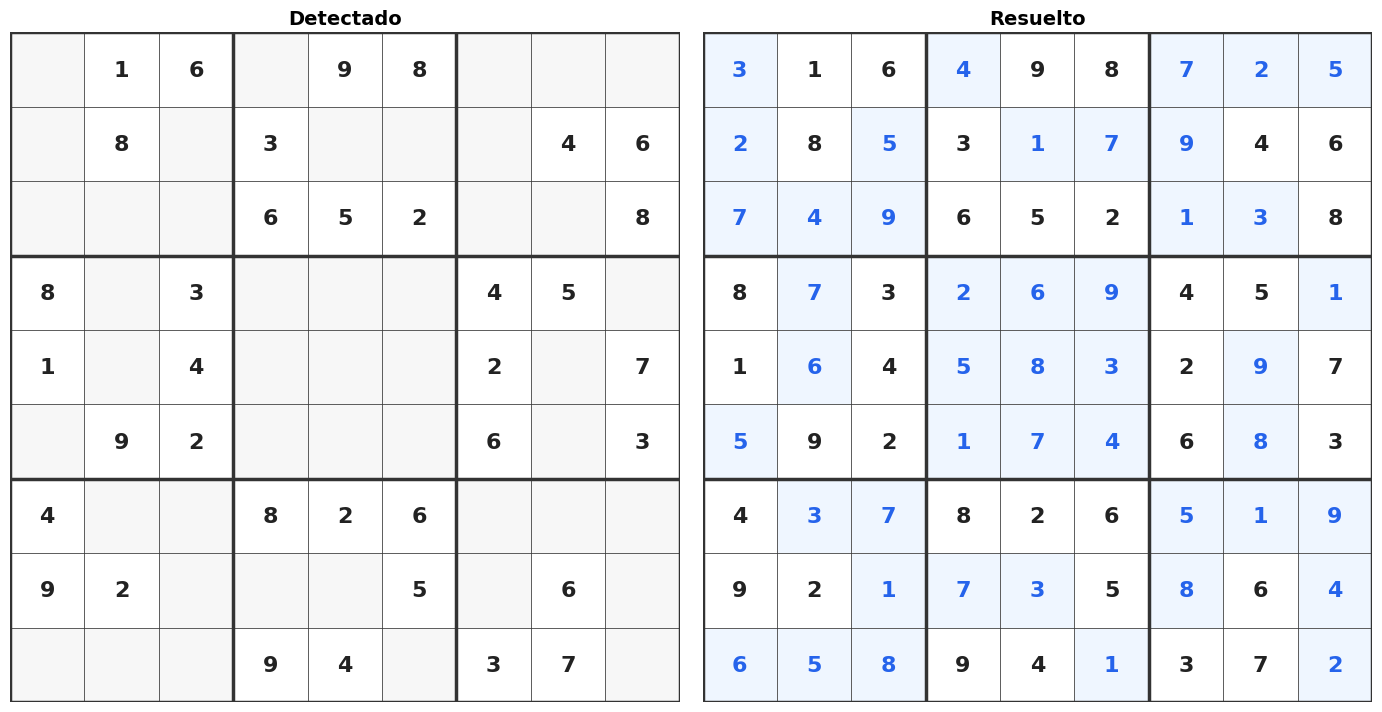

In [25]:
fig = plt.figure(figsize=(14, 7))
for idx, (datos, titulo) in enumerate([(sudoku, 'Detectado'), (tablero, 'Resuelto')]):
    ax = fig.add_subplot(1, 2, idx+1)
    ax.set_xlim(0, 9); ax.set_ylim(0, 9); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    for i in range(9):
        for j in range(9):
            d = datos[i][j]
            if titulo == 'Resuelto' and sudoku[i][j] == 0:
                color_txt, fondo = '#2563eb', '#eff6ff'
            elif d != 0:
                color_txt, fondo = '#222', '#ffffff'
            else:
                color_txt, fondo = '#222', '#f7f7f7'
            ax.add_patch(plt.Rectangle((j, 8-i), 1, 1, facecolor=fondo, edgecolor='#bbb', lw=0.5))
            if d != 0:
                ax.text(j+0.5, 8-i+0.5, str(d), ha='center', va='center',
                        fontsize=16, fontweight='bold', color=color_txt)
    for k in range(10):
        lw = 2.5 if k % 3 == 0 else 0.5
        ax.axhline(k, color='#333', lw=lw); ax.axvline(k, color='#333', lw=lw)
plt.tight_layout()
plt.show()